In [39]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.service import Service
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
import numpy as np

# 🔹 Chrome WebDriver 설정 및 실행
options = webdriver.ChromeOptions()
# options.add_argument("--headless")  # 브라우저 창 없이 실행하려면 활성화 (테스트 후 제거 가능)
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

In [ ]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

url = "https://www.kyobobook.co.kr/"
driver.get(url)

search_box = driver.find_element(By.ID, "searchKeyword")
search_box.send_keys("머신러닝")
search_box.send_keys(Keys.RETURN)

driver.implicitly_wait(5)

book_titles = driver.find_elements(By.CSS_SELECTOR, "#shopData_list > ul div.prod_area.horizontal > div.prod_info_box > div.auto_overflow_wrap.prod_name_group > div.auto_overflow_contents > div > a span:nth-child(2)")

print("검색된 '머신러닝' 관련 도서 목록: ")

for idx, title in enumerate(book_titles[:10], start=1):
    print(f"{idx}, {title.text}")

driver.quit()

검색된 '머신러닝' 관련 도서 목록: 
1, The Hundred-Page Machine Learning Book
2, 인공지능엔지니어
3, 머신러닝 알고리즘
4, 머신러닝 엔지니어 - 머신러닝 (Machine Learning), 인공지능 (Artificial Intelligence), 데이터 분석 (Data Analysis), 딥러닝 (Deep Learning), 알고리즘 (Algorithm), 모델링 (Modeling), 예측 분석 (Predictive Analysis) 외
5, 혼자 공부하는 머신러닝+딥러닝
6, 케라스 창시자에게 배우는 딥러닝
7, 핸즈온 머신러닝
8, 챗GPT 시대 살아남기
9, 혼자 공부하는 머신러닝+딥러닝
10, 으뜸 데이터 분석과 머신러닝


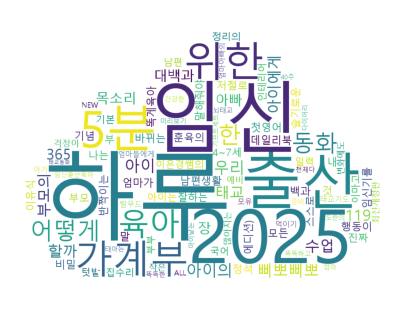

In [47]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

url = "https://www.yes24.com/Main/default.aspx"
driver.get(url)

inside = driver.find_element(By.CSS_SELECTOR, "#bigbanner_domestic_area > h3 > a")
inside.click()

inside = driver.find_element(By.CSS_SELECTOR, "#mCateLi > li:nth-child(1) > a")
inside.click()

dataset = []

for i in range(2, 8):
    driver.find_element(By.CSS_SELECTOR, f"#category001001001 > ul:nth-child({i})").click()
    driver.implicitly_wait(5)

    for j in range(1, 40):
        try:
            title = driver.find_element(By.CSS_SELECTOR, f"#yesNewList > li:nth-child({j}) > div > div.item_info > div.info_row.info_name > a.gd_name")
            dataset.append(title.text.split())
        except Exception as e:
            break

driver.quit()

temp = []
for i in dataset:
    temp.extend(i)
data = Counter((i for i in temp))
sorted_data = sorted(data.items(), key=lambda x : -x[1])

data_dict = {}
for k, v in sorted_data[:100]:
    data_dict[k] = v

# 워드 클라우드 생성

mask = np.array(Image.open("C:/Users/human/ku-python/data/img.png"))

wordcloud = WordCloud(font_path='c:/Windows/Fonts/malgun.ttf',
                        relative_scaling = 0.2, mask=mask,
                        background_color='white',
                        ).generate_from_frequencies(data_dict)

plt.figure(figsize=(5,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


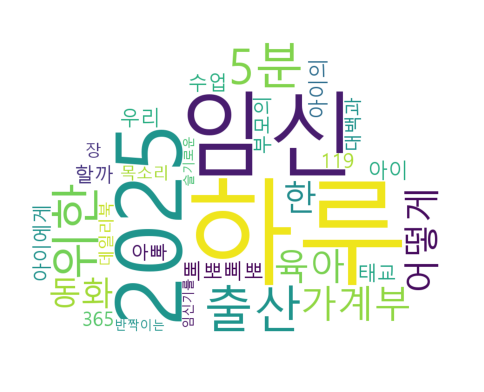

In [44]:
# 워드 클라우드 생성

mask = np.array(Image.open("C:/Users/human/ku-python/data/img.png"))

wordcloud = WordCloud(font_path='c:/Windows/Fonts/malgun.ttf',
                        relative_scaling = 0.2, mask=mask,
                        background_color='white',
                        ).generate_from_frequencies(data_dict)

plt.figure(figsize=(6,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


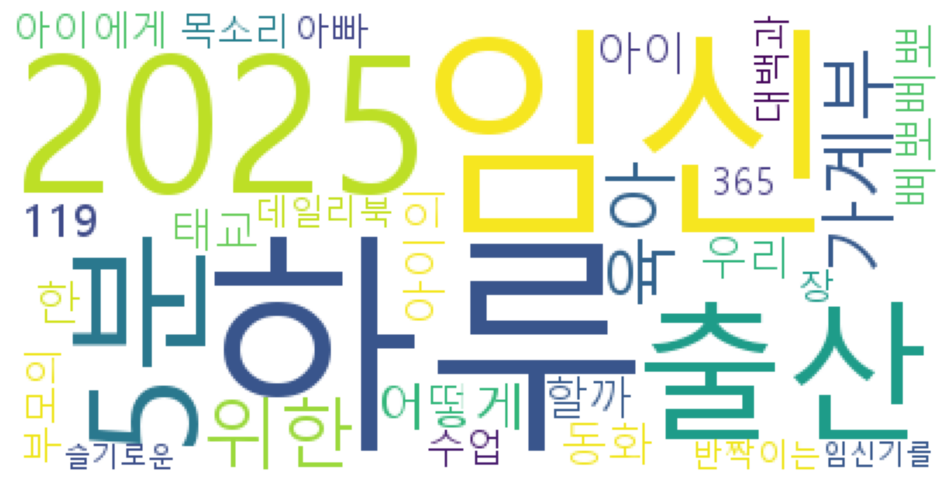